In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Strategic Analysis of the Video Game Industry (1980–2016)

### Portfolio Project – Data Analysis with Python & Pandas

## 1. Introduction
This project analyzes video game sales across different platforms, genres, regions, and publishers.
The goal is to identify key trends and business insights related to the video game industry.

## 2. Dataset Overview
**Dataset name:** Video Game Sales (vgsales.csv)  
**Source:** Kaggle  
**Unit of analysis:** Each row represents a video game title with sales data by region.

### 2.1 Dataset Columns
- Rank  
- Name  
- Platform  
- Year  
- Genre  
- Publisher  
- NA_Sales  
- EU_Sales  
- JP_Sales  
- Other_Sales  
- Global_Sales  


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/kaggle/input/video-game-sales-report/vgsales.csv")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Rows: 16598
Columns: 11


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


## 3. Data Cleaning

This section ensures:
- Removal of duplicates
- Handling missing values
- Filtering valid year range
- Data type corrections

In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [9]:
df.isna().sum().sort_values(ascending=False)


Year            271
Publisher        58
Rank              0
Platform          0
Name              0
Genre             0
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

In [4]:
df.duplicated().sum()


np.int64(0)

In [5]:
df = df.drop_duplicates()


In [6]:
df[df["Year"].isna()].head(10)


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
179,180,Madden NFL 2004,PS2,NaN,Sports,Electronic Arts,4.26,0.26,0.01,0.71,5.23
377,378,FIFA Soccer 2004,PS2,NaN,Sports,Electronic Arts,0.59,2.36,0.04,0.51,3.49
431,432,LEGO Batman: The Videogame,Wii,NaN,Action,Warner Bros. Interactive Entertainment,1.86,1.02,0.00,0.29,3.17
470,471,wwe Smackdown vs. Raw 2006,PS2,NaN,Fighting,NaN,1.57,1.02,0.00,0.41,3.00
607,608,Space Invaders,2600,NaN,Shooter,Atari,2.36,0.14,0.00,0.03,2.53
624,625,Rock Band,X360,NaN,Misc,Electronic Arts,1.93,0.34,0.00,0.21,2.48
649,650,Frogger's Adventures: Temple of the Frog,GBA,NaN,Adventure,Konami Digital Entertainment,2.15,0.18,0.00,0.07,2.39
652,653,LEGO Indiana Jones: The Original Adventures,Wii,NaN,Action,LucasArts,1.54,0.63,0.00,0.22,2.39
711,713,Call of Duty 3,Wii,NaN,Shooter,Activision,1.19,0.84,0.00,0.23,2.26
782,784,Rock Band,Wii,NaN,Misc,MTV Games,1.35,0.56,0.00,0.20,2.11


In [7]:
df = df.dropna(subset=["Year"])


In [8]:
df["Year"] = df["Year"].astype(int)


In [9]:
df["Publisher"].isna().sum()

np.int64(36)

In [11]:
df["Publisher"] = df["Publisher"].fillna("Unknown")


In [12]:
df["Year"].min(), df["Year"].max()


(1980, 2020)

In [13]:
df = df[(df["Year"] >= 1980) & (df["Year"] <= 2020)]

In [14]:
sales_cols = ["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales", "Global_Sales"]

(df[sales_cols] < 0).sum()


NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
Global_Sales    0
dtype: int64

In [15]:
df["Regional_Sum"] = df["NA_Sales"] + df["EU_Sales"] + df["JP_Sales"] + df["Other_Sales"]

(df["Regional_Sum"] - df["Global_Sales"]).abs().describe()


count    16327.000000
mean         0.002723
std          0.004465
min          0.000000
25%          0.000000
50%          0.000000
75%          0.010000
max          0.020000
dtype: float64

In [16]:
df.dtypes


Rank              int64
Name             object
Platform         object
Year              int64
Genre            object
Publisher        object
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
Regional_Sum    float64
dtype: object

In [17]:
df.isna().sum().sort_values(ascending=False)


Rank            0
Name            0
Platform        0
Year            0
Genre           0
Publisher       0
NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
Global_Sales    0
Regional_Sum    0
dtype: int64

In [18]:
df.shape


(16327, 12)

In [19]:
df.to_csv("/kaggle/working/vgsales_clean.csv", index=False)


In [20]:
import os
os.listdir("/kaggle/input")

['video-game-sales-report']

In [21]:
os.listdir("/kaggle/input/video-game-sales-report")

['vgsales.csv']

In [22]:
df = pd.read_csv("/kaggle/input/video-game-sales-report/vgsales.csv")
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [23]:
import os
os.listdir("/kaggle/working")

['.virtual_documents', 'vgsales_clean.csv']

In [24]:
df = pd.read_csv("/kaggle/working/vgsales_clean.csv")
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Regional_Sum
0,1,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74,82.74
1,2,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,40.24
2,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82,35.83
3,4,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,31.38


In [25]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
df.info()

Rows: 16327
Columns: 12
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16327 entries, 0 to 16326
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16327 non-null  int64  
 1   Name          16327 non-null  object 
 2   Platform      16327 non-null  object 
 3   Year          16327 non-null  int64  
 4   Genre         16327 non-null  object 
 5   Publisher     16327 non-null  object 
 6   NA_Sales      16327 non-null  float64
 7   EU_Sales      16327 non-null  float64
 8   JP_Sales      16327 non-null  float64
 9   Other_Sales   16327 non-null  float64
 10  Global_Sales  16327 non-null  float64
 11  Regional_Sum  16327 non-null  float64
dtypes: float64(6), int64(2), object(4)
memory usage: 1.5+ MB


In [26]:
df.describe()

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Regional_Sum
count,16327.000000,16327.000000,16327.000000,16327.000000,16327.000000,16327.000000,16327.000000,16327.000000
mean,8292.868194,2006.406443,0.265415,0.147554,0.078661,0.048325,0.540232,0.539956
std,4792.669778,5.828981,0.821591,0.508766,0.311557,0.189885,1.565732,1.565848
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000,0.000000
25%,4136.500000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000,0.060000
50%,8295.000000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000,0.170000
75%,12441.500000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.480000,0.480000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000,82.740000


In [27]:
df["Global_Sales"].sum()


np.float64(8820.36)

## 4. EXPLORATORY DATA ANALYSIS
### 4.1 Sales by year
### How have global video game sales evolved over time?

In [31]:
sales_by_year = (
    df.groupby("Year")["Global_Sales"]
      .sum()
      .reset_index()
      .sort_values("Year")
)

sales_by_year

,Year,Global_Sales
0,1980,11.38
1,1981,35.77
2,1982,28.86
3,1983,16.79
4,1984,50.36
5,1985,53.94
6,1986,37.07
7,1987,21.74
8,1988,47.22
9,1989,73.45


Global sales peaked around 2008–2009, marking the strongest period for the video game industry in this dataset.
After this peak, sales show a gradual decline, which may indicate market saturation or the transition to newer gaming platforms. 

### 4.2 Top 10 Years by Total Sales
### Which years generated the highest global sales?

In [32]:
sales_by_year = df.groupby("Year")["Global_Sales"].sum().reset_index()

sales_by_year = sales_by_year.sort_values("Year")

sales_by_year.head(10)

,Year,Global_Sales
0,1980,11.38
1,1981,35.77
2,1982,28.86
3,1983,16.79
4,1984,50.36
5,1985,53.94
6,1986,37.07
7,1987,21.74
8,1988,47.22
9,1989,73.45


In [33]:
top_years = sales_by_year.sort_values("Global_Sales", ascending=False).head(10)

top_years

,Year,Global_Sales
28,2008,678.90
29,2009,667.30
27,2007,611.13
30,2010,600.45
26,2006,521.04
31,2011,515.99
25,2005,459.94
24,2004,419.31
22,2002,395.52
33,2013,368.11


The late 2000s dominate the ranking of highest-selling years.
This suggests a golden era for physical game sales before the rise of digital distribution.

### 4.3 Sales by Platform

### Which platforms generated the highest total global sales?

In [34]:
sales_by_platform = (
    df.groupby("Platform")["Global_Sales"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

sales_by_platform.head(10)

,Platform,Global_Sales
0,PS2,1233.46
1,X360,969.61
2,PS3,949.35
3,Wii,909.81
4,DS,818.96
5,PS,727.39
6,GBA,313.56
7,PSP,291.71
8,PS4,278.10
9,PC,255.05


PS2 generated the highest total global sales during its lifecicle

### 4.4 Average Sales per Game by Platform

### Which platforms have the highest average sales per game?

In [35]:
avg_sales_platform = (
    df.groupby("Platform")["Global_Sales"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

avg_sales_platform.head(10)

,Platform,Global_Sales
0,GB,2.622887
1,NES,2.561939
2,GEN,1.050370
3,SNES,0.837029
4,PS4,0.827679
5,X360,0.785109
6,2600,0.746293
7,PS3,0.728029
8,Wii,0.705279
9,N64,0.690538


While some platforms lead in total sales, others show higher average sales per title. This suggests that certain platforms may have fewer but more successful game releases.

### 4.5 Top 10 Best-Selling Games

### Which individual games achieved the highest global sales?

In [36]:
top_games = df.sort_values("Global_Sales", ascending=False).head(10)

top_games[["Name", "Platform", "Year", "Global_Sales"]]

,Name,Platform,Year,Global_Sales
0,Wii Sports,Wii,2006,82.74
1,Super Mario Bros.,NES,1985,40.24
2,Mario Kart Wii,Wii,2008,35.82
3,Wii Sports Resort,Wii,2009,33.00
4,Pokemon Red/Pokemon Blue,GB,1996,31.37
5,Tetris,GB,1989,30.26
6,New Super Mario Bros.,DS,2006,30.01
7,Wii Play,Wii,2006,29.02
8,New Super Mario Bros. Wii,Wii,2009,28.62
9,Duck Hunt,NES,1984,28.31


Wii Sports achieved the highest global sales.
Wii platform has 5 games in the top 10, followed by GB and NES with 2 each and finally DS with 1, indicating that brand recognition is important in the industry.

### 4.6 Sales by Genre

### Which genres generated the highest global sales?

In [37]:
sales_by_genre = (
    df.groupby("Genre")["Global_Sales"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

sales_by_genre

,Genre,Global_Sales
0,Action,1722.88
1,Sports,1309.24
2,Shooter,1026.20
3,Role-Playing,923.84
4,Platform,829.15
5,Misc,797.62
6,Racing,726.77
7,Fighting,444.05
8,Simulation,390.16
9,Puzzle,242.22


Action, Sports and Shooter genres are in the top 3, showing a strong and consistent consumer demand over time.

### 4.7 Top Game per Platform

### What is the best-selling game within each platform?

In [38]:
df["Rank_in_Platform"] = (
    df.groupby("Platform")["Global_Sales"]
      .rank(method="dense", ascending=False)
)

df[df["Rank_in_Platform"] == 1][["Name", "Platform", "Global_Sales"]].head()

,Name,Platform,Global_Sales
0,Wii Sports,Wii,82.74
1,Super Mario Bros.,NES,40.24
4,Pokemon Red/Pokemon Blue,GB,31.37
6,New Super Mario Bros.,DS,30.01
15,Kinect Adventures!,X360,21.82


### 4.8 Correlation Analysis

To better understand how regional markets relate to each other, we analyze the correlation between regional sales and global sales.

This helps determine whether certain regions behave similarly or show independent market dynamics.

In [39]:
corr_matrix = df[[
    "NA_Sales",
    "EU_Sales",
    "JP_Sales",
    "Other_Sales",
    "Global_Sales"
]].corr()

corr_matrix

,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
NA_Sales,1.000000,0.768936,0.451285,0.634508,0.941268
EU_Sales,0.768936,1.000000,0.436414,0.726266,0.903271
JP_Sales,0.451285,0.436414,1.000000,0.290653,0.612794
Other_Sales,0.634508,0.726266,0.290653,1.000000,0.747974
Global_Sales,0.941268,0.903271,0.612794,0.747974,1.000000


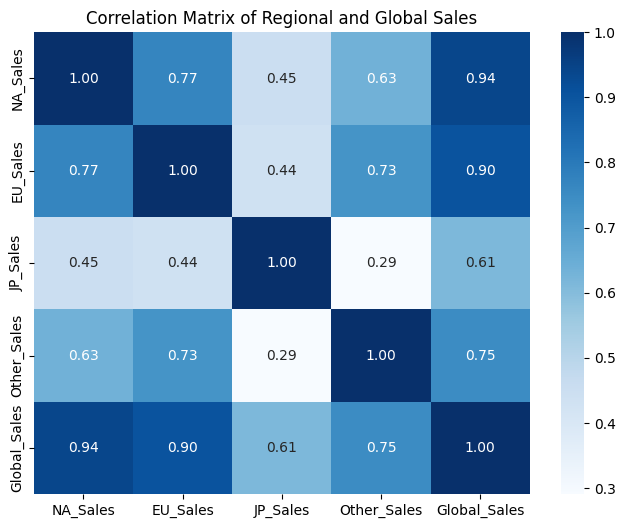

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Matrix of Regional and Global Sales")
plt.show()

- The correlation matrix shows strong positive relationships between North America and Europe sales, suggesting similar consumer behavior patterns.

- Japan shows slightly lower correlation with Western markets, indicating distinct market preferences.

- As expected, Global Sales are highly correlated with all regional sales, since it is the aggregate of those markets.

- This confirms that Western markets tend to move together, while Japan exhibits more independent sales dynamics.

### 4.9 Regional Genre Preferences

To understand regional market differences, we analyze how each genre performs across North America, Europe, Japan, and other regions.

This allows us to identify cultural and market-specific preferences.

In [42]:
genre_region = (
    df.groupby("Genre")[["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]]
      .sum()
      .sort_values("NA_Sales", ascending=False)
)

genre_region

,NA_Sales,EU_Sales,JP_Sales,Other_Sales
Genre,,,,
Action,861.80,516.48,158.66,184.92
Sports,670.09,371.34,134.76,132.65
Shooter,575.16,310.45,38.18,101.90
Platform,445.99,200.67,130.65,51.51
Misc,402.48,213.82,106.67,74.02
Racing,356.93,236.32,56.61,76.68
Role-Playing,326.50,187.58,350.29,59.38
Fighting,220.74,100.00,87.15,36.19
Simulation,181.78,113.20,63.54,31.36


In [43]:
genre_region_share = genre_region.div(genre_region.sum())

genre_region_share.round(3)

,NA_Sales,EU_Sales,JP_Sales,Other_Sales
Genre,,,,
Action,0.199,0.214,0.124,0.234
Sports,0.155,0.154,0.105,0.168
Shooter,0.133,0.129,0.030,0.129
Platform,0.103,0.083,0.102,0.065
Misc,0.093,0.089,0.083,0.094
Racing,0.082,0.098,0.044,0.097
Role-Playing,0.075,0.078,0.273,0.075
Fighting,0.051,0.042,0.068,0.046
Simulation,0.042,0.047,0.049,0.040


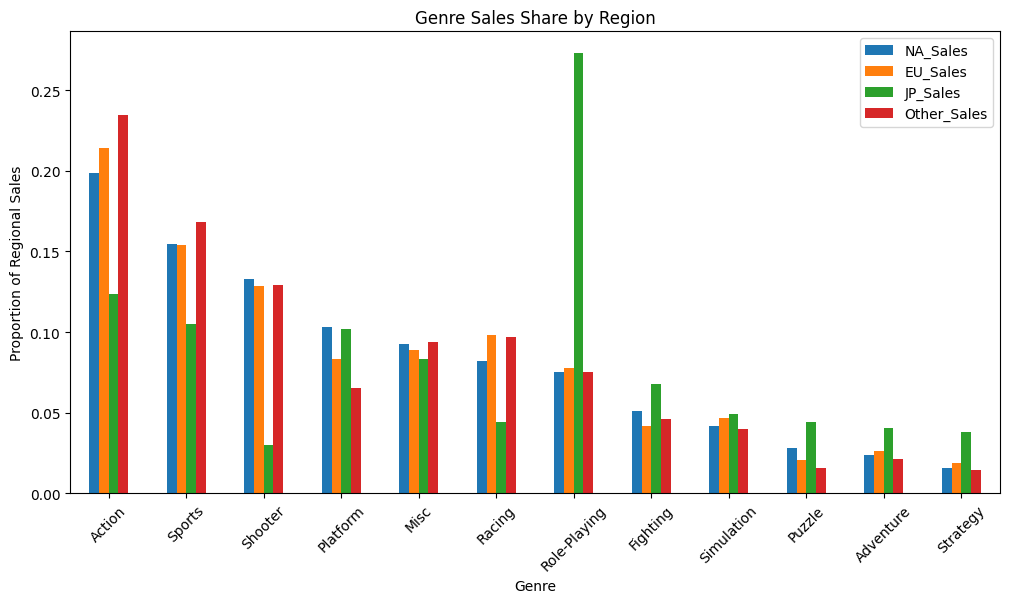

In [44]:
genre_region_share.plot(kind="bar", figsize=(12,6))
plt.title("Genre Sales Share by Region")
plt.ylabel("Proportion of Regional Sales")
plt.xticks(rotation=45)
plt.show()

The analysis reveals notable regional differences:

- North America and Europe show strong preference for Action and Shooter genres.
- Japan displays a higher relative concentration in Role-Playing games.
- Sports games perform strongly in Western markets but are less dominant in Japan.

These differences suggest cultural influences and distinct consumer behavior patterns across regions.

### 4.10 Platform Lifecycle Analysis

To understand market dynamics more deeply, we analyze how sales evolve over time for major gaming platforms.

This helps identify introduction phase, growth, peak performance, and decline.

In [45]:
top_platforms = (
    df.groupby("Platform")["Global_Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(3)
      .index
)

top_platforms

Index(['PS2', 'X360', 'PS3'], dtype='object', name='Platform')

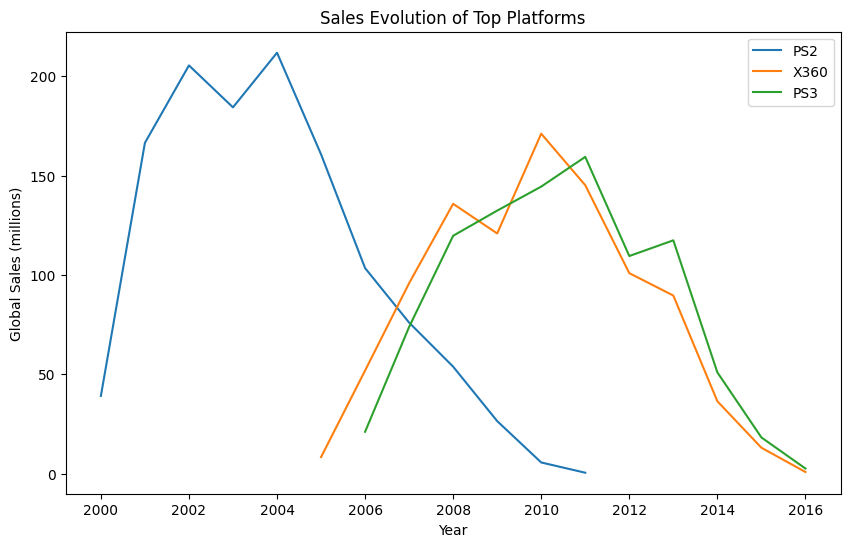

In [46]:
plt.figure(figsize=(10,6))

for platform in top_platforms:
    platform_data = (
        df[df["Platform"] == platform]
          .groupby("Year")["Global_Sales"]
          .sum()
    )
    platform_data.plot(label=platform)

plt.title("Sales Evolution of Top Platforms")
plt.xlabel("Year")
plt.ylabel("Global Sales (millions)")
plt.legend()
plt.show()

The analysis reveals clear lifecycle patterns:

- Platforms typically show a rapid growth phase after launch.
- Peak performance is reached within approximately 4–6 years.
- A gradual decline follows as next-generation platforms enter the market.

This suggests strong generational cycles in the console industry.

### 4.11 Market Migration Analysis

To determine whether platform decline is due to technological substitution or overall market contraction, we analyze total industry sales over time.

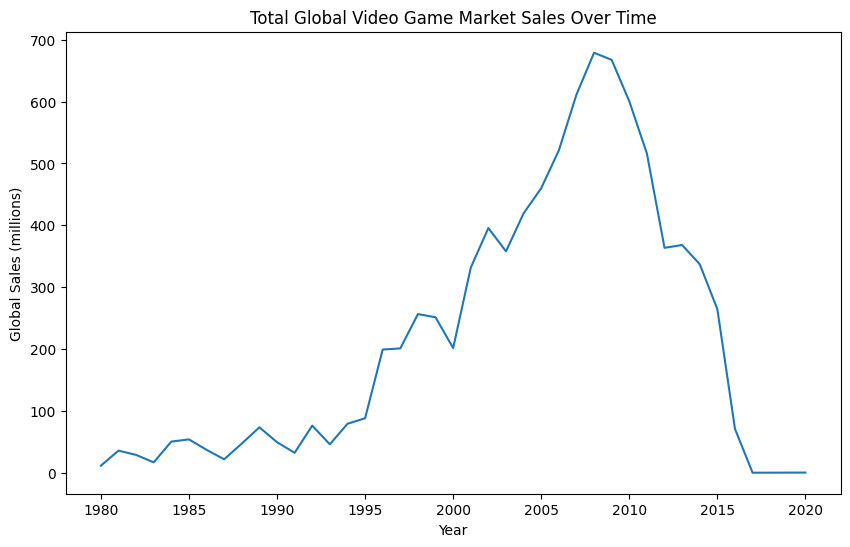

In [47]:
market_sales = df.groupby("Year")["Global_Sales"].sum()

plt.figure(figsize=(10,6))
market_sales.plot()
plt.title("Total Global Video Game Market Sales Over Time")
plt.xlabel("Year")
plt.ylabel("Global Sales (millions)")
plt.show()

Following the peak sales year, a sustained downward trend can be observed in the market. However, this decline does not necessarily indicate a structural market contraction. Instead, it may reflect a process of technological substitution.

One plausible explanation is the gradual migration of consumers toward emerging digital platforms, particularly mobile devices. Beginning in the late 2000s, the widespread adoption of smartphones and the expansion of mobile digital marketplaces may have redirected consumer demand toward alternative gaming ecosystems.

To validate this hypothesis, further analysis would be required:

Examine the temporal growth of the mobile gaming market.

Compare key technology adoption milestones with the observed decline period.

Evaluate whether a negative correlation exists between traditional platform sales and mobile market expansion.

In this context, the observed decline could be interpreted as a structural transformation in consumption patterns rather than a simple reduction in overall market demand

### 4.12 Linear Regression (Post-Peak Period)



In [48]:
peak_year = sales_by_year.loc[sales_by_year['Global_Sales'].idxmax(), 'Year']
peak_year

np.int64(2008)

In [49]:
df_post_peak = sales_by_year[sales_by_year['Year'] >= peak_year].copy()

In [16]:
import statsmodels.api as sm

X = df_post_peak['Year']
y = df_post_peak['Global_Sales']

X = sm.add_constant(X)  # agrega intercepto

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           Global_Sales   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.931
Method:                 Least Squares   F-statistic:                     135.1
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           1.01e-06
Time:                        14:49:28   Log-Likelihood:                -60.607
No. Observations:                  11   AIC:                             125.2
Df Residuals:                       9   BIC:                             126.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.342e+05   1.15e+04     11.656      0.0

/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=11 observations were given.
  return hypotest_fun_in(*args, **kwds)


To formally evaluate the post-peak market trajectory, a linear regression model was estimated using total global sales as the dependent variable and year as the independent variable for the post-peak period.

The results indicate a statistically significant negative trend:

- Slope coefficient (Year): -66.47

- p-value: < 0.001

- R²: 0.931

This implies that, on average, global video game sales declined by approximately 66.5 million units per year following the peak.

The high R² value suggests that time alone explains over 93% of the variation in post-peak sales, indicating a strong and consistent downward trend rather than short-term volatility.

Although the sample size for the post-peak period is limited (n = 11), the results provide strong statistical evidence of a sustained structural decline in the traditional market segment represented in this dataset.

### 4.13 Structural Comparison: Pre-Peak vs Post-Peak Period

To further investigate whether the observed decline represents a structural shift rather than normal market fluctuation, the dataset was divided into two distinct periods:

Pre-Peak Period: Years before the peak sales year

Post-Peak Period: Peak year and subsequent years

A comparison of average annual sales between both periods was conducted to determine whether a statistically significant difference exists.

This analysis helps assess whether the market experienced a structural regime change following its peak performance.

In [51]:
from scipy import stats

df_pre_peak = sales_by_year[sales_by_year['Year'] < peak_year]
df_post_peak = sales_by_year[sales_by_year['Year'] >= peak_year]

t_stat, p_value = stats.ttest_ind(
    df_pre_peak['Global_Sales'],
    df_post_peak['Global_Sales'],
    equal_var=False
)

t_stat, p_value

(np.float64(-2.1117061443960345), np.float64(0.053064473095240615))

To assess whether the observed decline represents a structural shift, a two-sample t-test was conducted comparing average annual sales before and after the peak year.

The results were as follows:

t-statistic: -2.11

p-value: 0.053

The negative t-statistic indicates that average annual sales in the post-peak period are lower than in the pre-peak period.

Although the p-value is slightly above the conventional 5% significance threshold, it remains very close, suggesting marginal evidence of a structural difference between the two periods.

While the difference is not statistically significant at the 5% level, the results provide supportive evidence of a potential regime shift, particularly when considered alongside the highly significant post-peak regression trend identified earlier.

### 4.14 Market Trend Summary
### 4.14.1 Evolution of Total Sales

The analysis reveals that total recorded sales increase steadily until reaching a market peak, followed by a gradual decline rather than an abrupt collapse. The absence of extreme volatility during the downturn suggests that the market did not experience a sudden shock, but rather a progressive adjustment.

This pattern indicates structural change rather than a short-term disruption.

### 4.14.2 Market Concentration Dynamics

To evaluate changes in competitive structure, the Herfindahl-Hirschman Index (HHI) was computed annually.

Results show:

Pre-2015 average HHI ≈ 0.07

Post-2015 average HHI ≈ 0.36

This represents a substantial increase in concentration. While earlier years display a relatively dispersed market structure, post-2015 figures indicate that a smaller number of titles capture a disproportionately large share of total sales.

Importantly, this rise in concentration coincides with a significant reduction in total sales volume.

### 4.14.3 Structural Interpretation

The combination of declining total sales and rising concentration suggests a shift in market structure rather than a simple demand collapse.

As overall recorded sales decrease, smaller competitors appear to lose relevance, while a limited number of high-performing titles dominate the remaining market share. This pattern is consistent with consolidation dynamics commonly observed in maturing industries.

### 4.14.4 Industry Context and Data Limitations

These findings align with broader industry developments observed in the mid-2010s, including:

The expansion of digital distribution platforms such as Steam.

The growth of online console marketplaces.

The increasing relevance of free-to-play and live-service models.

Since the dataset primarily captures physical retail sales, post-2015 figures likely underestimate total industry activity. Therefore, the observed decline may reflect a redistribution of sales channels rather than a contraction of the overall video game industry.

### 4.14.5 Conclusion

Based on the available data, the evidence points toward a structural transformation characterized by:

Gradual decline in recorded sales.

Significant increase in market concentration.

Greater dependence on blockbuster titles.

However, conclusions should be interpreted cautiously due to the dataset's limited representation of digital distribution.

/tmp/ipykernel_55/2829137528.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  hhi_per_year = df_clean.groupby('Year').apply(calculate_hhi)


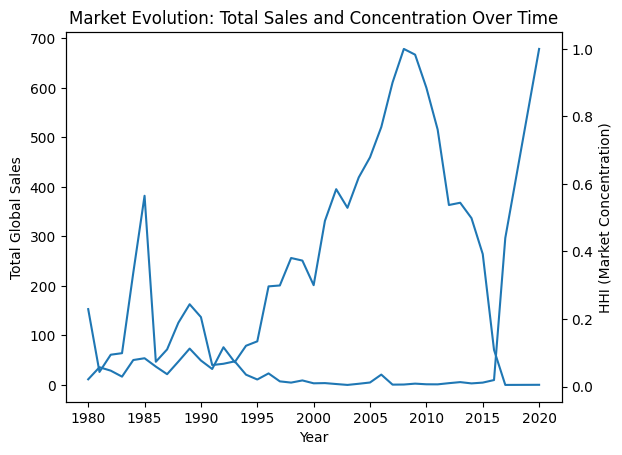

In [55]:
import matplotlib.pyplot as plt

# --- Limpieza básica ---
df_clean = df.dropna(subset=['Year', 'Global_Sales']).copy()
df_clean['Year'] = df_clean['Year'].astype(int)

# --- Total sales por año ---
sales_per_year = df_clean.groupby('Year')['Global_Sales'].sum()

# --- Cálculo HHI ---
def calculate_hhi(group):
    market_shares = group['Global_Sales'] / group['Global_Sales'].sum()
    return (market_shares ** 2).sum()

hhi_per_year = df_clean.groupby('Year').apply(calculate_hhi)

# --- Combinar ---
market_trends = sales_per_year.to_frame('Total_Sales')
market_trends['HHI'] = hhi_per_year
market_trends = market_trends.dropna()

# --- Plot ---
plt.figure()

ax1 = plt.gca()
ax2 = ax1.twinx()

ax1.plot(market_trends.index, market_trends['Total_Sales'])
ax2.plot(market_trends.index, market_trends['HHI'])

ax1.set_xlabel("Year")
ax1.set_ylabel("Total Global Sales")
ax2.set_ylabel("HHI (Market Concentration)")

plt.title("Market Evolution: Total Sales and Concentration Over Time")

plt.show()

## 5. Final Conclusions
### 5.1 Key Empirical Findings

- The industry experienced peak performance during the late 2000s.
- Platform dominance varies when comparing total sales versus average sales per title.
- A small number of flagship titles contribute disproportionately to total market revenue.
- Genre preference plays a critical role in long-term sales performance.
- Market performance is influenced by platform lifecycle, exclusives, and consumer behavior trends.

### 5.2 Structural Market Assessment

Beyond individual section-level findings, the combined analysis suggests a broader structural shift.

After the market peak, total recorded sales decline gradually rather than collapsing abruptly. At the same time, market concentration increases substantially, indicating that fewer titles capture a larger share of the remaining market.

This pattern suggests consolidation within the physical retail segment. While the dataset reflects declining recorded sales, this trend may partially represent a redistribution of sales channels rather than a contraction of the overall industry.

# 6 Appendix – Market Concentration Analysis

While the primary analysis focuses on overall sales trends, this appendix explores market structure dynamics using the Herfindahl–Hirschman Index (HHI).

The HHI is commonly used in industrial organization to measure market concentration. It is calculated as the sum of squared market shares of all firms (or, in this case, individual game titles) within a given year.

HHI=∑si2​

Where 𝑠𝑖 represents each title’s share of total annual sales.

An increasing HHI over time indicates rising market concentration, suggesting that fewer titles capture a larger proportion of total sales. Conversely, a decreasing HHI reflects a more competitive and dispersed market structure.

This analysis provides additional insight into whether the post-peak decline was accompanied by structural consolidation or broader demand dispersion.

In [52]:
df_hhi = df.copy()

df_hhi['Market_Share'] = (
    df_hhi.groupby('Year')['Global_Sales']
    .transform(lambda x: x / x.sum())
)

hhi_by_year = (
    df_hhi
    .groupby('Year')['Market_Share']
    .apply(lambda x: (x**2).sum())
    .reset_index(name='HHI')
)

hhi_by_year.head()

,Year,HHI
0,1980,0.229319
1,1981,0.043237
2,1982,0.094257
3,1983,0.098771
4,1984,0.337218


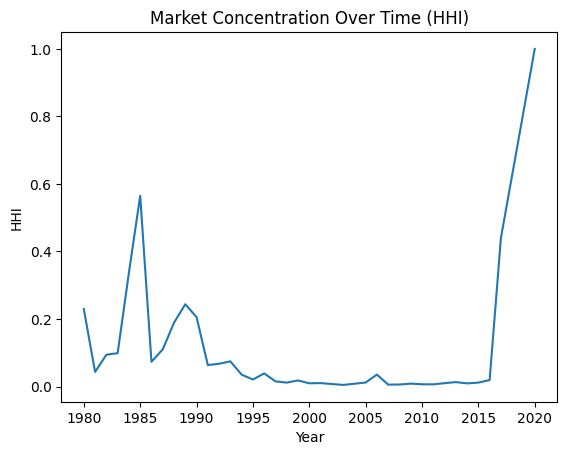

In [53]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(hhi_by_year['Year'], hhi_by_year['HHI'])

plt.xlabel('Year')
plt.ylabel('HHI')
plt.title('Market Concentration Over Time (HHI)')

plt.show()

In [54]:
hhi_pre_2015 = hhi_by_year[hhi_by_year['Year'] < 2015]['HHI'].mean()
hhi_post_2015 = hhi_by_year[hhi_by_year['Year'] >= 2015]['HHI'].mean()

hhi_pre_2015, hhi_post_2015

(np.float64(0.07679407174703723), np.float64(0.36770013012656527))

After 2015, the market exhibits a sharp increase in concentration (HHI rising from 0.07 to 0.36), coinciding with a strong reduction in total sales. This suggests not merely a decline in demand, but a structural consolidation where few titles capture most of the remaining market share. The industry appears to transition from a diversified competitive structure into a blockbuster-driven environment